# Ptychography tutorial 02 (full)

This notebook shows the full modular ptychography workflow in quantEM.
Compared with the lite tutorial, this version exposes the object/probe/detector models and reconstruction settings in more detail.

Arthur McCray  
November 7, 2025

In [1]:
%load_ext autoreload
%autoreload 2 

In [2]:
from pathlib import Path

import numpy as np
import torch

import quantem as em
from quantem.core import config
from quantem.core.datastructures import Dataset4dstem
from quantem.core.ml import CNN2d, OptimizerParams, SchedulerParams
from quantem.core.visualization import show_2d
from quantem.diffractive_imaging import (
    DetectorPixelated,
    ObjectDIP,
    ObjectINR,
    ObjectPixelated,
    ObjectTensorDecomp,
    ProbeDIP,
    ProbePixelated,
    Ptychography,
    PtychographyDatasetRaster,
)

print(f"quantEM version: {em.__version__}")

GPU_ID = 0
config.set_device(GPU_ID)
print(f"Using GPU {config.get('device')}")

/home/amccray/code/quantem/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


quantEM version: 0.1.8
Using GPU cuda:2


## Load the `ducky` dataset
We start from the bundled simulated 4D-STEM dataset and set core probe parameters used throughout the notebook.

In [3]:
filepath = Path("../../data/ducky_251105_20mrad_500A-df_4A-step_5e+04-dose_clean.zip")
dset: Dataset4dstem = em.io.load(filepath)
print(dset)

PROBE_ENERGY = 80e3  # eV, accelerating voltage
PROBE_SEMIANGLE = 20  # mrad, convergence semiangle
PROBE_DEFOCUS = 500  # A, probe defocus

quantem Dataset named 'ducky_251105_clean'
  shape: (37, 37, 200, 200)
  dtype: float32
  device: cpu
  origin: [0. 0. 0. 0.]
  sampling: [4.    4.    0.025 0.025]
  units: ['A', 'A', 'A^-1', 'A^-1']
  signal units: 'arb. units'


(<Figure size 400x400 with 1 Axes>,
 <Axes: title={'center': 'ducky_251105_clean_dp_mean'}>)

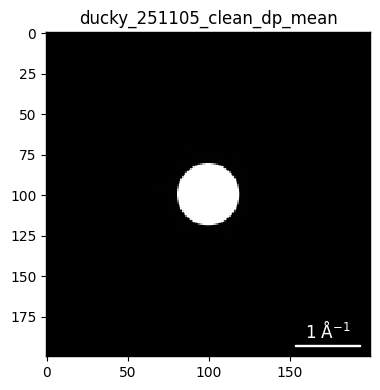

In [4]:
dset.dp_mean.show(show_ticks=True)

In [ ]:
# Binning in reciprocal space is limited here because the probe support must still fit.
# Optional example:
# dset_small = dset.bin((1,1,2,2), modify_in_place=False)

## Pixelated ptychography
First we run a standard pixelated reconstruction to establish a baseline before moving to DIP.

quantEM ptychography is intentionally modular, so each physical component is represented by its own model:
- Object model: sample representation (for example pixelated or DIP).
- Probe model: electron probe parameterization and optimization strategy.
- Detector model: detector response and measurement mapping.
- Dataset model: scan geometry and indexing of diffraction measurements.

If a built-in model does not match your experiment, you can implement a compatible custom model and plug it into the same workflow.

Next we initialize each sub-model.

Most quantEM classes use classmethod constructors (instead of direct `__init__`) to keep setup explicit and reduce configuration mistakes.

Calculated best fit rotation = 0 degrees.


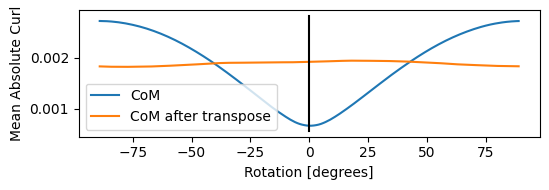

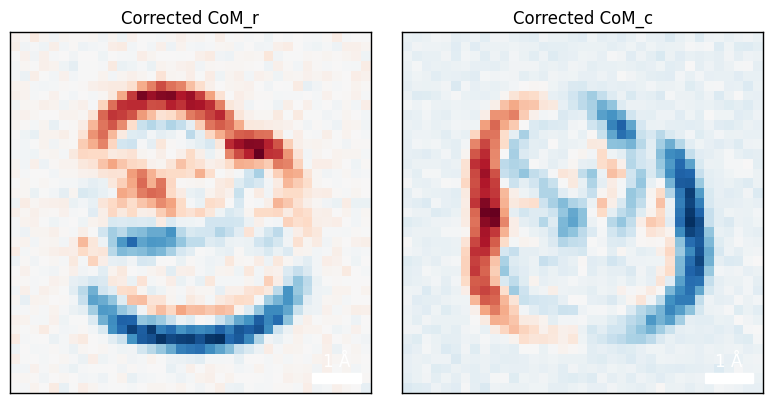

Normalizing intensities: 100%|██████████| 1369/1369 [00:01<00:00, 848.42probe position/s]


In [6]:
pdset = PtychographyDatasetRaster.from_dataset4dstem(dset)
pdset.preprocess(
    com_fit_function="constant",
    plot_rotation=True,
    plot_com=True,
)

obj_model_pix = ObjectPixelated.from_uniform(  # Alternatives include from_array and from_random.
    obj_type="pure_phase",
    num_slices=1,
)

probe_params = {
    "energy": PROBE_ENERGY,
    "defocus": PROBE_DEFOCUS,
    "semiangle_cutoff": PROBE_SEMIANGLE,
}
probe_model_pix = ProbePixelated.from_params(
    probe_params=probe_params,
)

detector_model = DetectorPixelated()

In [7]:
# Optional: enable TensorBoard logging while iterating on settings.
from quantem.diffractive_imaging.logger_ptychography import LoggerPtychography

logger_pix = None
# logger_pix = LoggerPtychography(
#     log_dir = "./logs",
#     run_prefix=dset.name,
#     run_suffix="pix",
#     log_images_every=10,
#     log_probe_images=False,
# )

After the sub-models are ready, we combine them into a `Ptychography` instance with `Ptychography.from_models(...)`.

In [8]:
ptycho_pix = Ptychography.from_models(
    dset=pdset,
    obj_model=obj_model_pix,
    probe_model=probe_model_pix,
    detector_model=detector_model,
    logger=logger_pix,
    rng=42,
)

`Ptychography.preprocess(...)` runs additional setup checks and bookkeeping before optimization.
If the dataset has not already been preprocessed, this step can also trigger dataset preprocessing.
In practice, preprocessing the dataset explicitly beforehand is usually clearer.

In [9]:
ptycho_pix.preprocess(
    obj_padding_px=(32, 32),
    val_ratio=0.0,
)

Now we run the reconstruction loop.

Key controls are passed as parameter dictionaries (for optimizer, scheduler, and data loading behavior).
The optimizer configuration is the most important: object, probe, and dataset modules can each use different learning rates or even different optimizer types.

In [10]:
?OptimizerParams

Init signature: OptimizerParams()
Docstring:     
Container for optimizer parameter dataclasses.

Each nested class configures a specific PyTorch optimizer and can be passed
directly to ``OptimizerMixin.set_optimizer``, or constructed from a dict via
``OptimizerParams.parse_dict``.

Supported optimizers
--------------------
Adam
    ``torch.optim.Adam`` — adaptive moment estimation.
AdamW
    ``torch.optim.AdamW`` — Adam with decoupled weight decay.
SGD
    ``torch.optim.SGD`` — stochastic gradient descent with optional momentum and Nesterov.
NoneOptimizer
    Sentinel that disables / removes the optimizer.

Examples
--------
>>> obj.set_optimizer(OptimizerParams.Adam(lr=1e-4))
>>> obj.set_optimizer({"name": "adam", "lr": 1e-4})  # equivalent dict form
File:           ~/code/quantem/src/quantem/core/ml/optimizer_mixin.py
Type:           type
Subclasses:     

Iter 50/50, Loss: 4.938e+00: 100%|██████████| 50/50 [00:03<00:00, 15.15it/s]


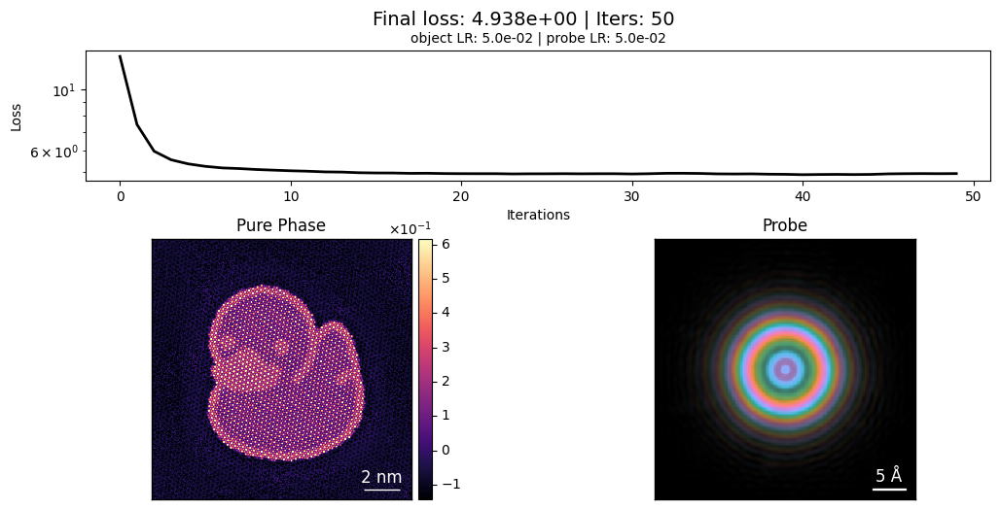

In [11]:
opt_params = {
    "object": OptimizerParams.Adam(lr=5e-2),
    "probe": OptimizerParams.Adam(lr=5e-2),
}

scheduler_params = {
    "object": SchedulerParams.Plateau(factor=0.1),
    "probe": SchedulerParams.Plateau(factor=0.1),
}

ptycho_pix.reconstruct(
    num_iters=50,
    reset=True,
    optimizer_params=opt_params,
    scheduler_params=scheduler_params,
    batch_size=125,
    device="gpu",
).visualize()

In [12]:
### To view TensorBoard logs, uncomment and run:
# %load_ext tensorboard
# %tensorboard --logdir=./logs/ --port=6007 # Port 6007 avoids occasional conflicts with 6006.
# print(f"TensorBoard will be available at: http://localhost:6007")


  0%|          | 0/200 [00:00<?, ?it/s]

Iter 200/200, Loss: 4.400e+00: 100%|██████████| 200/200 [00:12<00:00, 16.59it/s]


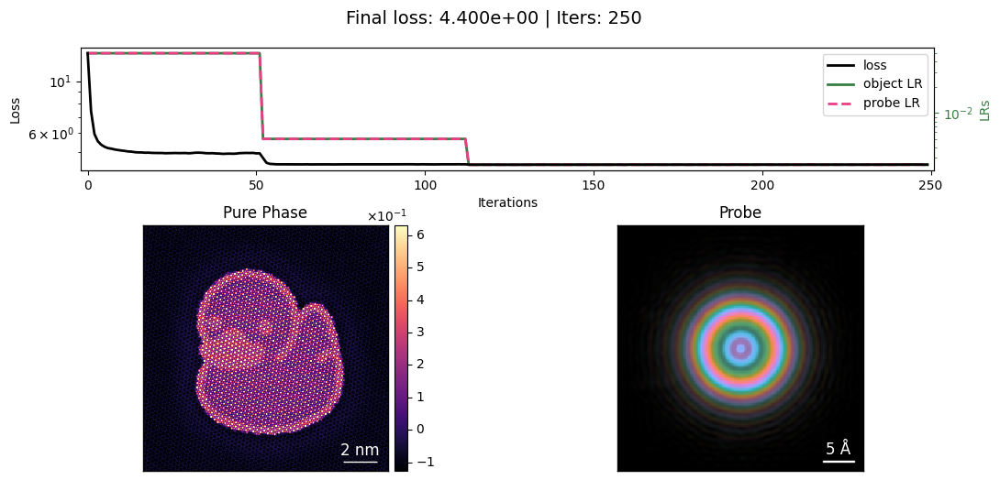

In [13]:
ptycho_pix.reconstruct(
    num_iters=200,
).visualize()

(<Figure size 1200x400 with 3 Axes>,
 array([<Axes: title={'center': 'pixelated pure_phase | 250 iters'}>,
        <Axes: title={'center': 'zoom region 1'}>,
        <Axes: title={'center': 'zoom region 2'}>], dtype=object))

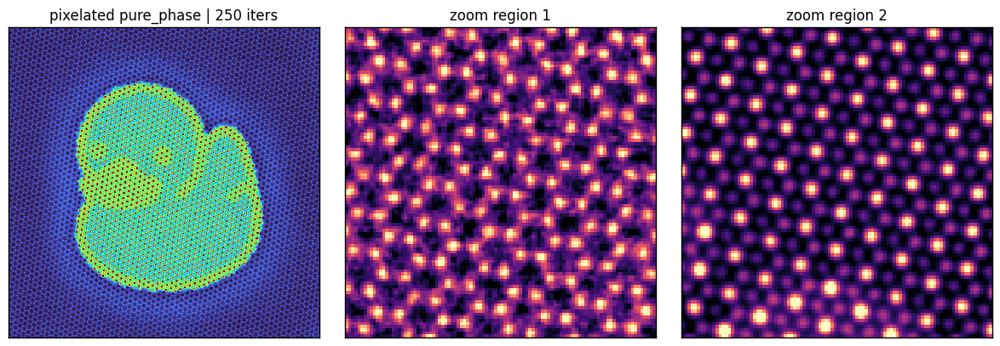

In [14]:
r1 = slice(10, 110), slice(10, 110)
r2 = slice(220, 320), slice(220, 320)
ph = ptycho_pix.obj_cropped.sum(0)
if ptycho_pix.obj_model.obj_type == "complex":
    ph = np.angle(ph)
show_2d(
    [
        ph,
        ph[r1],
        ph[r2],
    ],
    cmap=("turbo", "magma", "magma"),
    title=[
        f"pixelated {ptycho_pix.obj_model.obj_type} | {ptycho_pix.num_iters} iters",
        "zoom region 1",
        "zoom region 2",
    ],
)

You can continue reconstruction from the current state, optionally with updated optimizer settings.
Setting an optimizer type to `"none"` is a convenient way to freeze that module during later iterations.

## Deep image prior (DIP)
With the pixelated baseline in place, we switch to a DIP object model and compare behavior.

Iter 5/5, Loss: 5.363e+00: 100%|██████████| 5/5 [00:04<00:00,  1.06it/s]


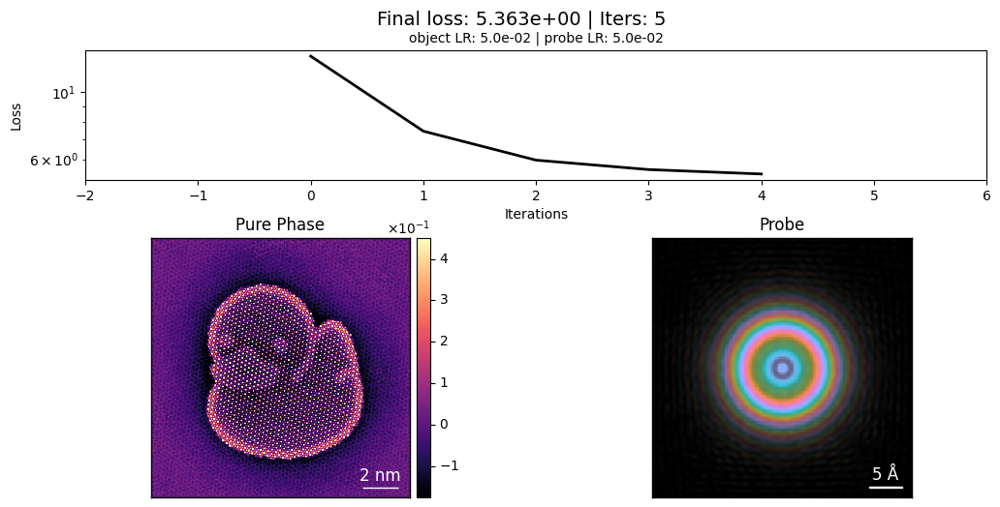

In [15]:
ptycho_pix2 = Ptychography.from_ptychography(
    ptycho=ptycho_pix,
)
ptycho_pix2.reconstruct(
    num_iters=5,
    reset=True,
).visualize()

In [16]:
logger_dip = None
# logger_dip = LoggerPtychography(
#     log_dir = "./logs",
#     run_prefix=dset.name,
#     run_suffix="DIP",
#     log_images_every=10,
#     log_probe_images=False,
# )

  0%|          | 0/100 [00:00<?, ?it/s]

Iter 100/100, Loss: 8.335e-04, : 100%|██████████| 100/100 [00:01<00:00, 52.85it/s]


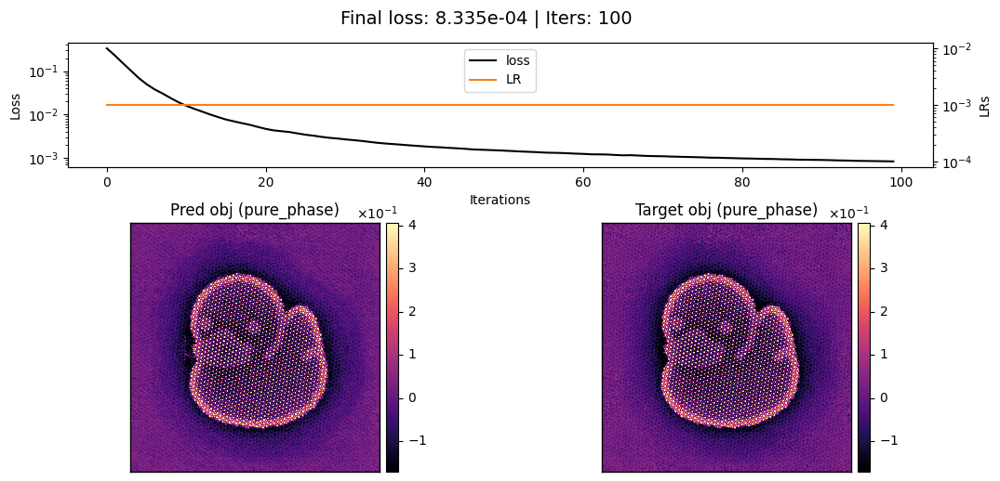

Iter 50/50, Loss: 1.602e-02, : 100%|██████████| 50/50 [00:00<00:00, 54.67it/s]


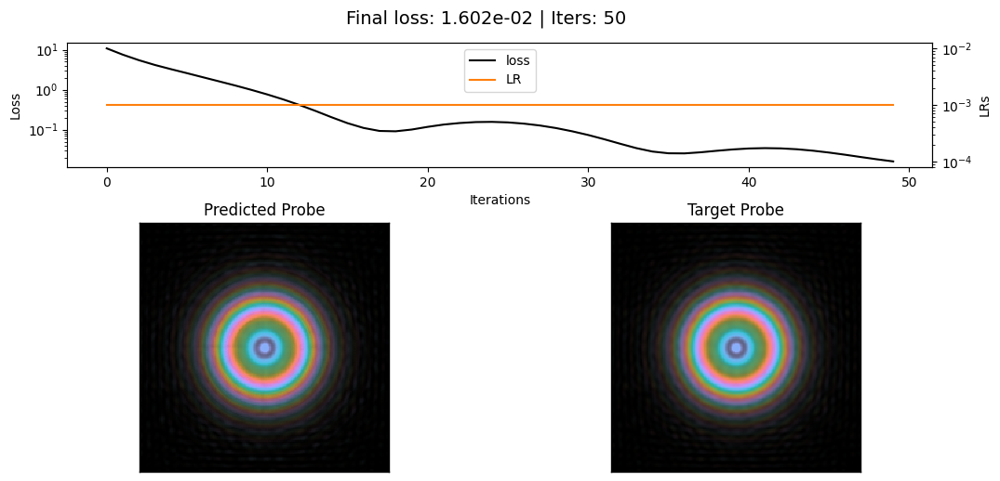

In [17]:
model_dip = CNN2d(
    in_channels=ptycho_pix2.num_slices,
    use_skip_connections=True,
    dtype=torch.complex64 if ptycho_pix2.obj_model.obj_type == "complex" else torch.float32,
    final_activation="softplus" if ptycho_pix2.obj_model.obj_type == "potential" else "identity",
)
obj_model_dip = ObjectDIP.from_pixelated(
    model=model_dip,
    pixelated=ptycho_pix2.obj_model,
)

probe_dip = CNN2d(
    in_channels=1,
    use_skip_connections=True,
    dtype=torch.complex64,
)
probe_model_dip = ProbeDIP.from_pixelated(
    model=probe_dip,
    pixelated=ptycho_pix2.probe_model,
)

obj_model_dip.pretrain(
    num_iters=100,
    optimizer_params=OptimizerParams.Adam(lr=1e-3),
    scheduler_params=SchedulerParams.Plateau(factor=0.5),
    device=config.get("device"),
)

probe_model_dip.pretrain(
    num_iters=50,
    optimizer_params=OptimizerParams.Adam(lr=1e-3),
    scheduler_params=SchedulerParams.Plateau(factor=0.5),
    device=config.get("device"),
)

ptycho_dip = Ptychography.from_models(
    dset=pdset,
    obj_model=obj_model_dip,
    probe_model=probe_model_dip,
    detector_model=detector_model,
    device=config.get("device"),
    logger=logger_dip,
)

ptycho_dip.preprocess(
    obj_padding_px=(32, 32),
)

  0%|          | 0/25 [00:00<?, ?it/s]

Iter 25/25, Loss: 4.701e+00: 100%|██████████| 25/25 [00:12<00:00,  2.07it/s]


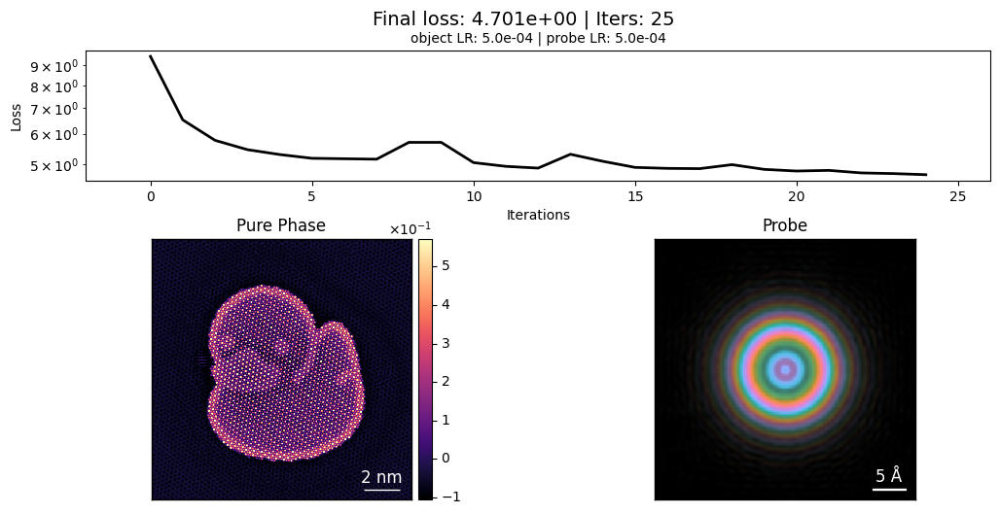

In [18]:
opt_params = {
    "object": OptimizerParams.Adam(lr=5e-4),
    "probe": OptimizerParams.Adam(lr=5e-4),
}

scheduler_params = {
    "object": SchedulerParams.Plateau(),
    "probe": SchedulerParams.Plateau(),
}
ptycho_dip.reconstruct(
    num_iters=25,
    reset=True,
    optimizer_params=opt_params,
    scheduler_params=scheduler_params,
    batch_size=128,
    device="gpu",
    store_snapshots_every=1,
).visualize()

(<Figure size 1200x400 with 3 Axes>,
 array([<Axes: title={'center': 'DGP pure_phase | 25 iters'}>,
        <Axes: title={'center': 'zoom region 1'}>,
        <Axes: title={'center': 'zoom region 2'}>], dtype=object))

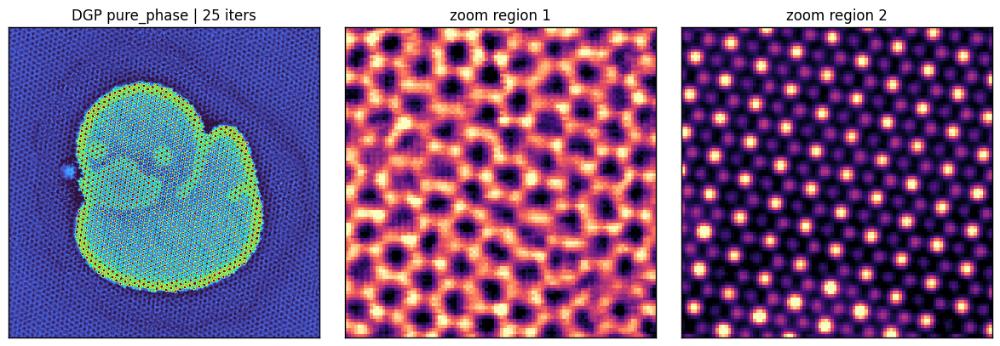

In [19]:
ph = ptycho_dip.obj_cropped.sum(0)
if ptycho_dip.obj_model.obj_type == "complex":
    ph = np.angle(ph)
show_2d(
    [
        ph,
        ph[r1],
        ph[r2],
    ],
    cmap=("turbo", "magma", "magma"),
    title=[
        f"DGP {ptycho_dip.obj_model.obj_type} | {ptycho_dip.num_iters} iters",
        "zoom region 1",
        "zoom region 2",
    ],
)

  0%|          | 0/25 [00:00<?, ?it/s]

Iter 25/25, Loss: 4.561e+00: 100%|██████████| 25/25 [00:12<00:00,  2.06it/s]


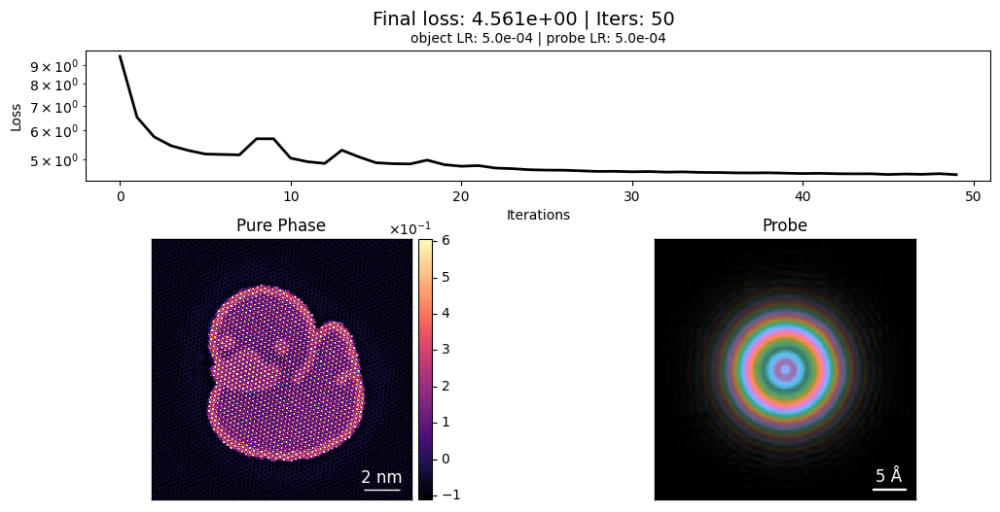

In [20]:
ptycho_dip.reconstruct(25).visualize()

(<Figure size 1200x400 with 3 Axes>,
 array([<Axes: title={'center': 'DGP pure_phase | 50 iters'}>,
        <Axes: title={'center': 'zoom region 1'}>,
        <Axes: title={'center': 'zoom region 2'}>], dtype=object))

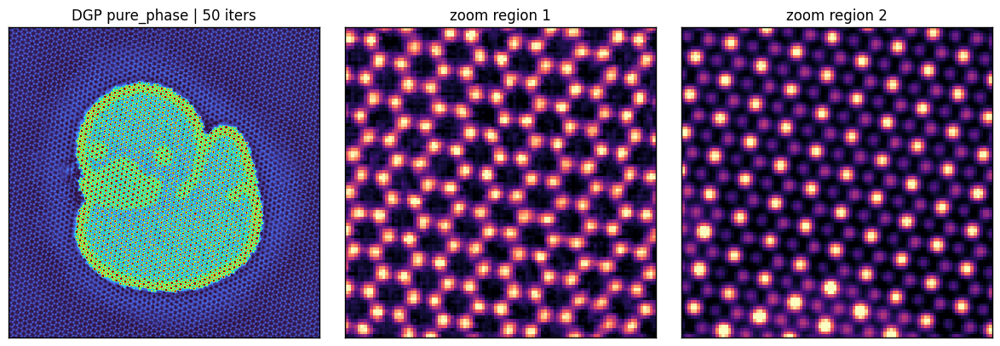

In [21]:
ph = ptycho_dip.obj_cropped.sum(0)
if ptycho_dip.obj_model.obj_type == "complex":
    ph = np.angle(ph)
show_2d(
    [
        ph,
        ph[r1],
        ph[r2],
    ],
    cmap=("turbo", "magma", "magma"),
    title=[
        f"DGP {ptycho_dip.obj_model.obj_type} | {ptycho_dip.num_iters} iters",
        "zoom region 1",
        "zoom region 2",
    ],
)

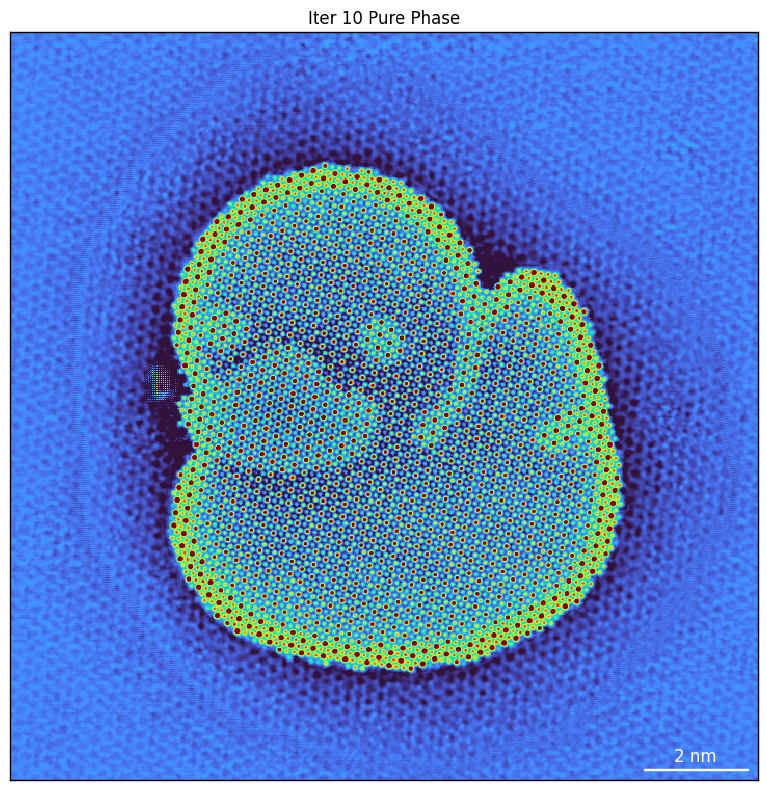

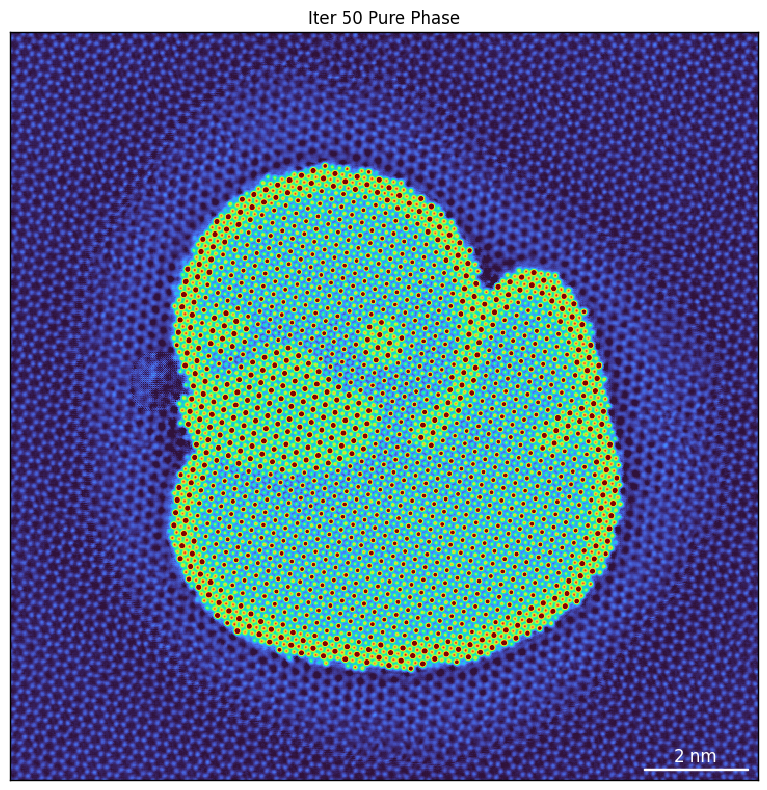

In [22]:
ptycho_dip.show_obj(snapshot_iter=10, axsize=(8, 8), cmap="turbo")
ptycho_dip.show_obj(snapshot_iter=50, axsize=(8, 8), cmap="turbo")

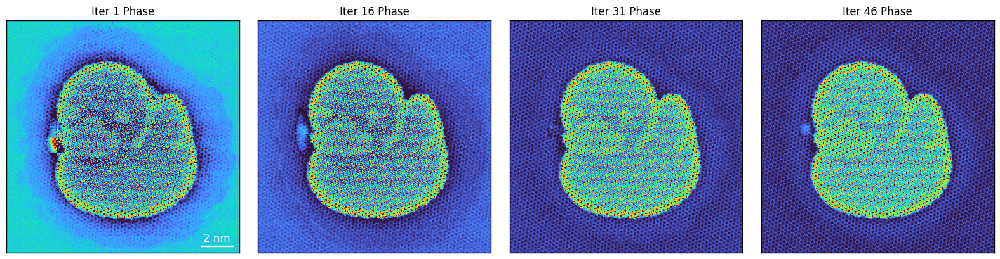

In [23]:
ptycho_dip.show_iters(
    show_probe=False,
    every_nth=15,
    cmap="turbo",
)

## Save and reload
Persisting the ptychography object lets you pause and resume long runs without rebuilding the full setup.

In [24]:
savedir = Path("../../outputs/diffractive_imaging")
savedir.mkdir(exist_ok=True)
ptycho_dip.save(savedir / "ptycho_dip.zip", mode="o")

Saving ptychography object to /home/amccray/code/quantem-tutorials/outputs/diffractive_imaging/ptycho_dip.zip


In [25]:
ptycho_dip2 = Ptychography.from_file(savedir / "ptycho_dip.zip", dset=pdset)

  0%|          | 0/5 [00:00<?, ?it/s]

Iter 5/5, Loss: 4.639e+00: 100%|██████████| 5/5 [00:02<00:00,  1.95it/s]


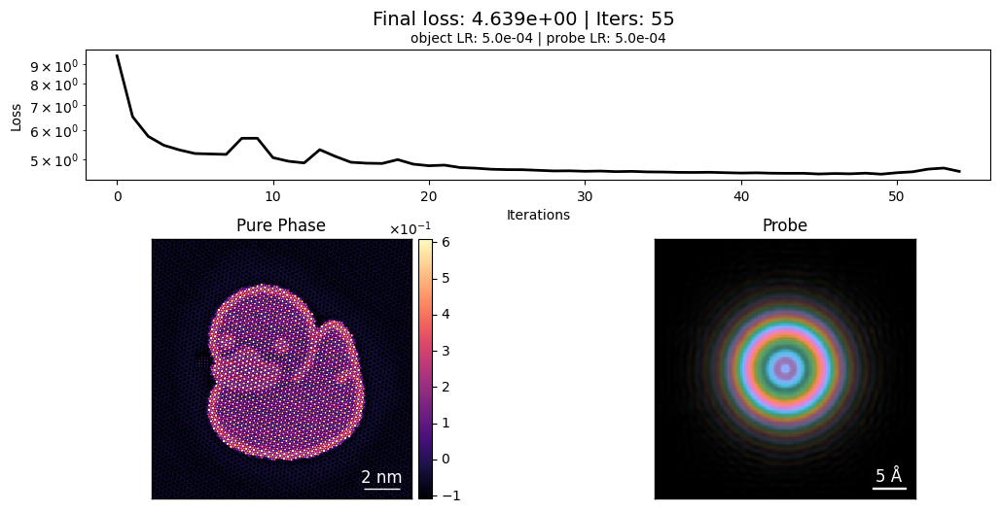

In [26]:
ptycho_dip2.reconstruct(
    num_iters=5,
    device="gpu",
).visualize()

(<Figure size 1200x400 with 3 Axes>,
 array([<Axes: title={'center': 'DGP pure_phase | 55 iters'}>,
        <Axes: title={'center': 'zoom region 1'}>,
        <Axes: title={'center': 'zoom region 2'}>], dtype=object))

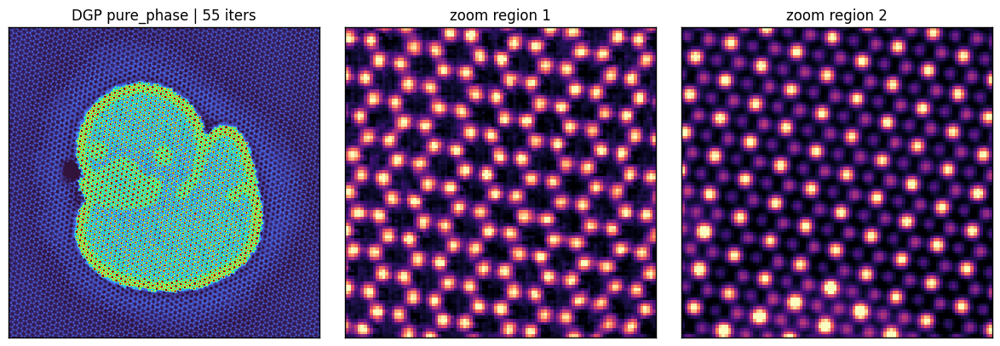

In [27]:
ph = ptycho_dip2.obj_cropped.sum(0)
if ptycho_dip2.obj_model.obj_type == "complex":
    ph = np.angle(ph)
show_2d(
    [
        ph,
        ph[r1],
        ph[r2],
    ],
    cmap=("turbo", "magma", "magma"),
    title=[
        f"DGP {ptycho_dip2.obj_model.obj_type} | {ptycho_dip2.num_iters} iters",
        "zoom region 1",
        "zoom region 2",
    ],
)

## Working with larger-than-VRAM datasets

When a 4D-STEM dataset is larger than a single GPU's memory, two
complementary tools help: CPU-resident diffraction targets, and a
preprocess-once / reconstruct-many save+reload workflow.


### CPU-resident diffraction targets

By default `PtychographyDatasetRaster` keeps all diffraction targets on the
compute device. Setting `pdset.target_residency = "cpu"` keeps them in CPU
RAM and streams batches to the GPU per step. Combined with `num_workers > 0`
(background prefetch), this trades a small per-batch transfer cost for the
ability to run reconstructions that wouldn't otherwise fit in VRAM.

Ducky is small enough that this isn't necessary, but the pattern looks like:


In [28]:
# pdset.target_residency = "cpu"
# ptycho_pix.reconstruct(
#     num_iters=50,
#     batch_size=128,
#     num_workers=2,   # background prefetch overlaps transfer with compute
#     device="gpu",
# ).visualize()

### Preprocess-once, reconstruct-many workflow

Multi-GPU dataset preprocessing (`pdset.preprocess(...)`) is **not currently
supported** — preprocessing has to happen on a single device. For very large
datasets the recommended pattern is:

1. Preprocess on a single GPU.
2. Save the preprocessed `Ptychography` to disk (`save_raw_data=True` keeps
   the diffraction patterns inside the archive so a reload is self-contained).
3. Restart the kernel to release the GPU memory used during preprocessing.
4. Reload via `Ptychography.from_file(...)` and run reconstruction — single-
   or multi-GPU — as many times as you like with different optimizer,
   constraint, and scheduler settings.

This also pays off whenever you want to iterate on hyperparameters or
constraints without re-paying the preprocessing cost. See
`ptycho_iter_08_multi_gpu.ipynb` for the multi-GPU launch details.


In [29]:
# # --- preprocessing kernel ---
# pdset = PtychographyDatasetRaster.from_dataset4dstem(dset)
# pdset.preprocess(com_fit_function="constant")
# ptycho_pix = Ptychography.from_models(
#     dset=pdset,
#     obj_model=ObjectPixelated.from_uniform(obj_type="pure_phase", num_slices=1),
#     probe_model=ProbePixelated.from_params(probe_params=probe_params),
#     detector_model=DetectorPixelated(),
# )
# ptycho_pix.preprocess(obj_padding_px=(32, 32))
# ptycho_pix.save("../../outputs/diffractive_imaging/ducky_preprocessed.zip", save_raw_data=True)

# # --- restart kernel here to free preprocessing memory ---

# # --- reconstruction kernel ---
# ptycho_pix = Ptychography.from_file("../../outputs/diffractive_imaging/ducky_preprocessed.zip")
# ptycho_pix.reconstruct(
#     num_iters=50,
#     optimizer_params={"object": OptimizerParams.Adam(lr=5e-2),
#                       "probe":  OptimizerParams.Adam(lr=5e-2)},
#     batch_size=125,
#     device=[0, 1],   # multi-GPU after the preprocessed state is reloaded
# ).visualize()

## Implicit object models (INR and K-Planes)

Beyond the pixelated grid and the DIP, the object can be represented implicitly as a small
network queried at continuous coordinates. Two options, both drop-in object models (swap them
into `from_models` and the dataset switches to coordinate queries automatically,
`dset.implicit_object`):

- **INR** (`ObjectINR`): a hSIREN mapping `(z, y, x) -> phase`. Powerful but sensitive to the
  SIREN frequency `omega_0`; warm-start it from the pixelated reconstruction and use a
  learning-rate scheduler.
- **K-Planes** (`ObjectTensorDecomp`): a multi-resolution feature grid + small decoder.
  Converges fast from scratch (no `omega_0` to tune) and uses **per-parameter-group learning
  rates (PPLR)** — separate rates for the feature `grids` and the `sigma_net` decoder. Converges 
  faster than hSIREN and is less expeinsive per iteration. 

The settings below reflect what hyperparameter sweeps found works best on this dataset
(INR: `omega_0`≈20, object lr `1e-3`; K-Planes: `grids` lr `1e-1`, `sigma_net` lr `1e-3`,
resolution 256+, single linear decoder). Both use a **DIP probe** (the same probe setup as the DIP section above), so the three
learned-object models (DIP, INR, K-Planes) are compared with an identical probe representation.

The INR models don't seem to work as well as DIP for normal single- or multi-slice ptycho, and therefore they aren't suggested for regular use. However they can be very valuable when doing 3D reconstructions as the object can be queried at any reference frame without interpolation. 

### INR 

Iter 3/50, Loss: 4.378e+00, :   0%|          | 0/50 [00:00<?, ?it/s]

Iter 50/50, Loss: 1.587e-02, : 100%|██████████| 50/50 [00:00<00:00, 54.77it/s]


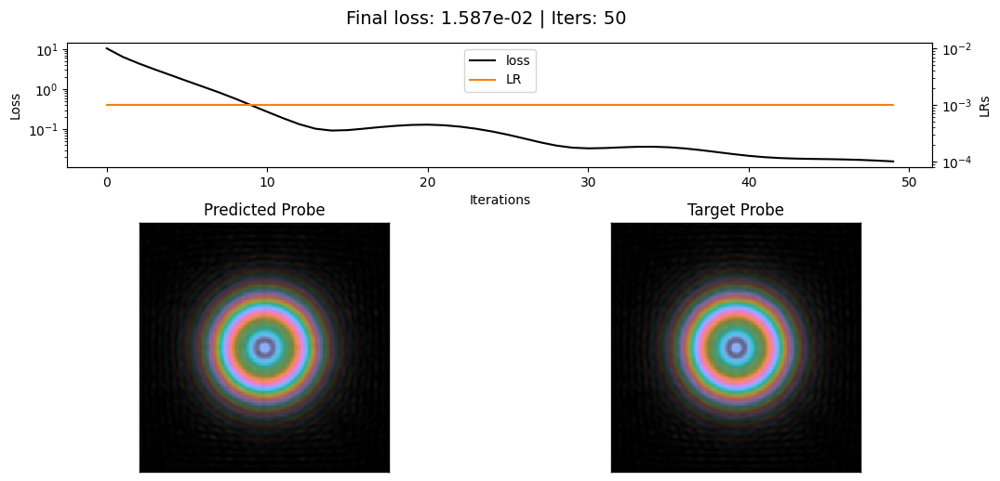

Iter 300/300, Loss: 3.038e-04: 100%|██████████| 300/300 [00:12<00:00, 24.66it/s]


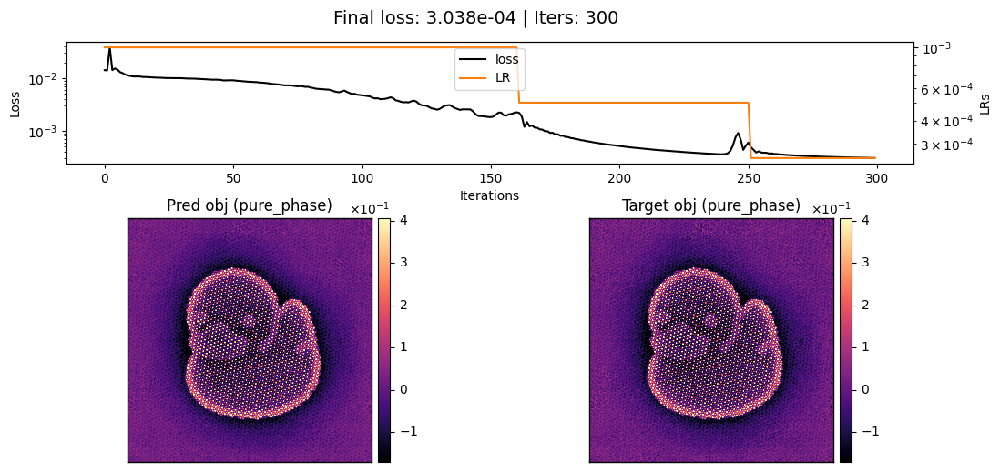

implicit object: True


In [30]:
# Initialize from ptycho_pix2 -- the deliberately under-converged (5-iter) pixelated start
# used by the DIP section -- so the learned-object models get a fair comparison (not handed
# the fully-converged pixelated result). The INR's pretrained weights become its reset state.
obj_model_inr = ObjectINR.from_pixelated(
    pixelated=ptycho_pix2.obj_model,
    first_omega_0=20,  # SIREN frequency scale -- the key INR knob (lower = smoother)
    hidden_omega_0=20,
    hidden_features=256,
)
# Use a DIP probe (set up exactly as in the DIP section above) so DIP / INR / K-Planes
# objects are all compared with the same best-performing probe representation.
probe_model_inr = ProbeDIP.from_pixelated(
    model=CNN2d(in_channels=1, use_skip_connections=True, dtype=torch.complex64),
    pixelated=ptycho_pix2.probe_model,
)
probe_model_inr.pretrain(
    num_iters=50,
    optimizer_params=OptimizerParams.Adam(lr=1e-3),
    scheduler_params=SchedulerParams.Plateau(factor=0.5),
    device=config.get("device"),
)
obj_model_inr.pretrain(
    num_iters=300,
    optimizer_params=OptimizerParams.Adam(lr=1e-3),
    scheduler_params=SchedulerParams.Plateau(factor=0.5),
    device=config.get("device"),
)
ptycho_inr = Ptychography.from_models(
    dset=pdset,
    obj_model=obj_model_inr,
    probe_model=probe_model_inr,
    detector_model=detector_model,
    device=config.get("device"),
    rng=42,
)
ptycho_inr.preprocess(obj_padding_px=(32, 32))
print("implicit object:", ptycho_inr.dset.implicit_object)

  0%|          | 0/50 [00:00<?, ?it/s]

Iter 50/50, Loss: 5.679e+00: 100%|██████████| 50/50 [03:06<00:00,  3.74s/it]


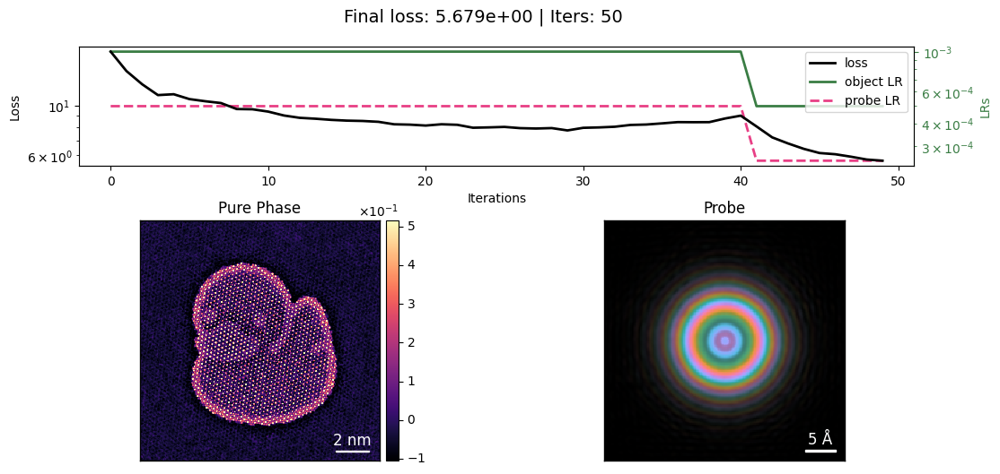

In [31]:
opt_params = {
    # The implicit object gets no analytic-gradient rescaling, so it wants a higher lr
    # than the pixelated object.
    "object": OptimizerParams.Adam(lr=1e-3),
    "probe": OptimizerParams.Adam(lr=5e-4),
}
scheduler_params = {
    "object": SchedulerParams.Plateau(),
    "probe": SchedulerParams.Plateau(),
}
ptycho_inr.reconstruct(
    num_iters=50,
    reset=True,
    optimizer_params=opt_params,
    scheduler_params=scheduler_params,
    batch_size=128,
    device="gpu",
).visualize()

(<Figure size 1200x400 with 3 Axes>,
 array([<Axes: title={'center': 'INR pure_phase | 50 iters'}>,
        <Axes: title={'center': 'zoom region 1'}>,
        <Axes: title={'center': 'zoom region 2'}>], dtype=object))

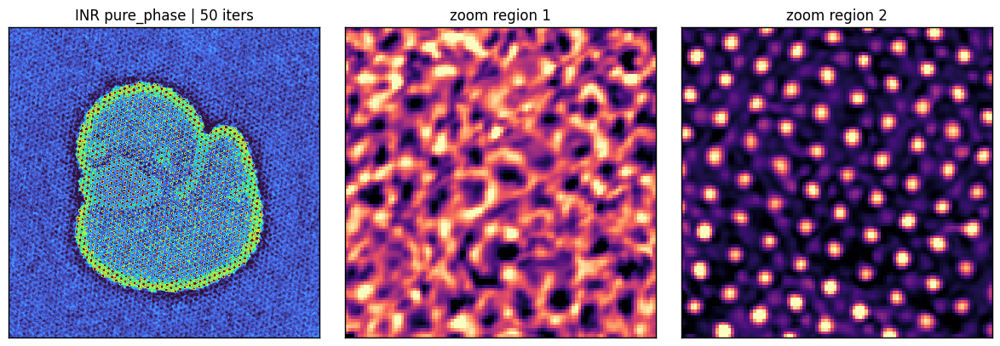

In [32]:
ph = ptycho_inr.obj_cropped.sum(0)
if ptycho_inr.obj_model.obj_type == "complex":
    ph = np.angle(ph)
show_2d(
    [ph, ph[r1], ph[r2]],
    cmap=("turbo", "magma", "magma"),
    title=[
        f"INR {ptycho_inr.obj_model.obj_type} | {ptycho_inr.num_iters} iters",
        "zoom region 1",
        "zoom region 2",
    ],
)

  0%|          | 0/50 [00:00<?, ?it/s]

Iter 50/50, Loss: 4.991e+00: 100%|██████████| 50/50 [03:06<00:00,  3.73s/it]


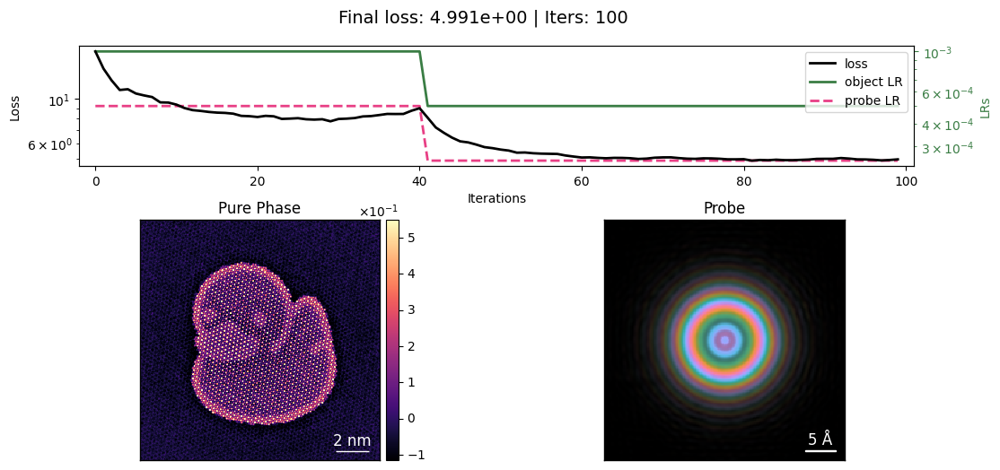

In [33]:
# Continue from the current state for a longer, higher-quality reconstruction.
ptycho_inr.reconstruct(num_iters=50).visualize()
# ptycho_inr.reconstruct(num_iters=100).visualize()

(<Figure size 1200x400 with 3 Axes>,
 array([<Axes: title={'center': 'INR pure_phase | 100 iters'}>,
        <Axes: title={'center': 'zoom region 1'}>,
        <Axes: title={'center': 'zoom region 2'}>], dtype=object))

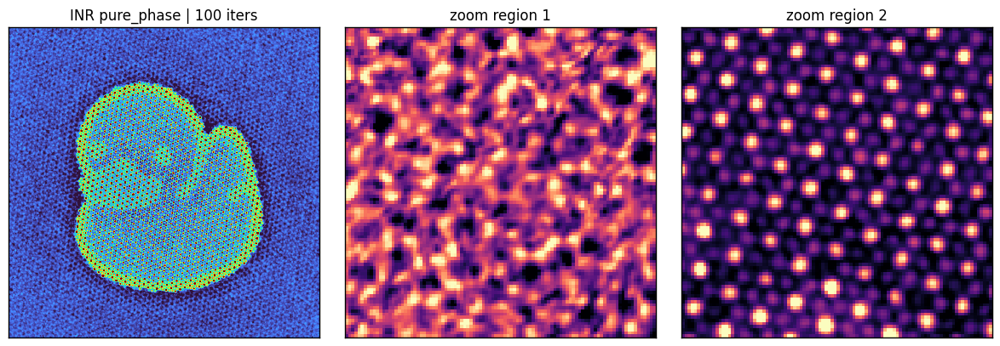

In [34]:
ph = ptycho_inr.obj_cropped.sum(0)
if ptycho_inr.obj_model.obj_type == "complex":
    ph = np.angle(ph)
show_2d(
    [ph, ph[r1], ph[r2]],
    cmap=("turbo", "magma", "magma"),
    title=[
        f"INR {ptycho_inr.obj_model.obj_type} | {ptycho_inr.num_iters} iters",
        "zoom region 1",
        "zoom region 2",
    ],
)

### K-Planes

A multi-resolution feature grid + linear decoder. Per-parameter-group learning rates: the
feature `grids` learn fast (`lr=1e-1`), the decoder `sigma_net` slower (`lr=1e-3`). No
pretraining needed — it converges from vacuum.

  0%|          | 0/50 [00:00<?, ?it/s]

Iter 50/50, Loss: 1.615e-02, : 100%|██████████| 50/50 [00:00<00:00, 63.61it/s]


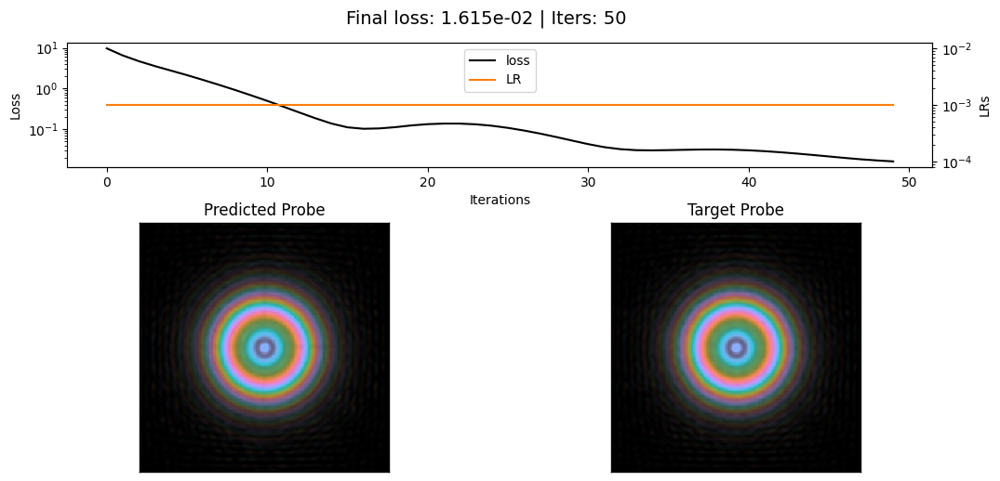

implicit object: True


In [35]:
obj_model_kp = ObjectTensorDecomp.from_uniform(
    num_slices=1,
    M_features=32,
    resolution=(
        256,
        256,
        256,
    ),  # feature-plane resolution; sweeps found 384 marginally better (higher memory)
    multiscale_res_multipliers=(0.25, 0.5, 1.0),
    use_hybrid_mlp=False,  # a single linear decoder beat the hybrid MLP in the sweeps
    obj_type="pure_phase",
    rng=42,
)
# Use a DIP probe (set up exactly as in the DIP section above) so DIP / INR / K-Planes
# objects are all compared with the same best-performing probe representation.
probe_model_kp = ProbeDIP.from_pixelated(
    model=CNN2d(in_channels=1, use_skip_connections=True, dtype=torch.complex64),
    pixelated=ptycho_pix2.probe_model,
)
probe_model_kp.pretrain(
    num_iters=50,
    optimizer_params=OptimizerParams.Adam(lr=1e-3),
    scheduler_params=SchedulerParams.Plateau(factor=0.5),
    device=config.get("device"),
)
ptycho_kp = Ptychography.from_models(
    dset=pdset,
    obj_model=obj_model_kp,
    probe_model=probe_model_kp,
    detector_model=detector_model,
    device=config.get("device"),
    rng=42,
)
ptycho_kp.preprocess(obj_padding_px=(32, 32))
print("implicit object:", ptycho_kp.dset.implicit_object)

Iter 50/50, Loss: 4.554e+00: 100%|██████████| 50/50 [02:00<00:00,  2.40s/it]


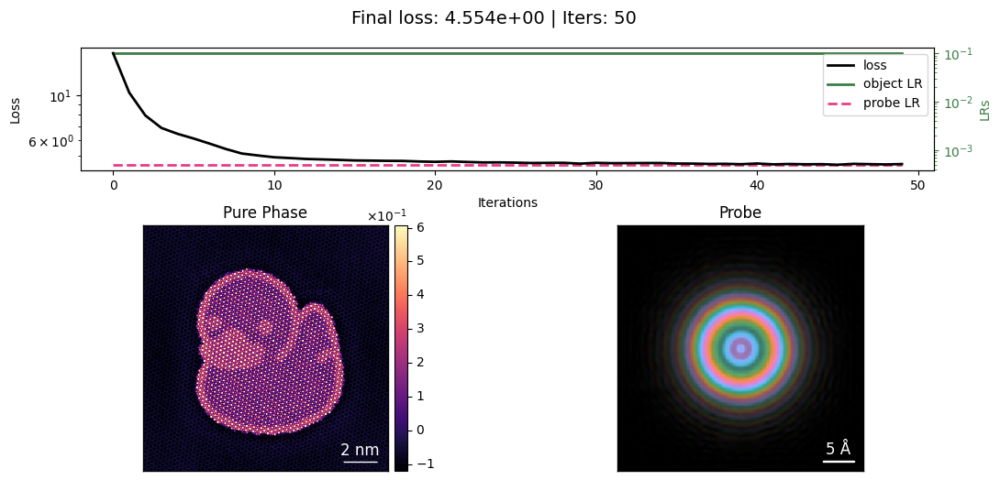

In [36]:
opt_params = {
    "object": {
        "grids": OptimizerParams.Adam(lr=1e-1),  # feature grids learn fast
        "sigma_net": OptimizerParams.Adam(lr=1e-3),  # the small decoder learns slower
    },
    "probe": OptimizerParams.Adam(lr=5e-4),
}
scheduler_params = {
    "object": SchedulerParams.Plateau(),
    "probe": SchedulerParams.Plateau(),
}
ptycho_kp.reconstruct(
    num_iters=50,
    reset=True,
    optimizer_params=opt_params,
    scheduler_params=scheduler_params,
    batch_size=128,
    device="gpu",
).visualize()

(<Figure size 1200x400 with 3 Axes>,
 array([<Axes: title={'center': 'K-Planes pure_phase | 50 iters'}>,
        <Axes: title={'center': 'zoom region 1'}>,
        <Axes: title={'center': 'zoom region 2'}>], dtype=object))

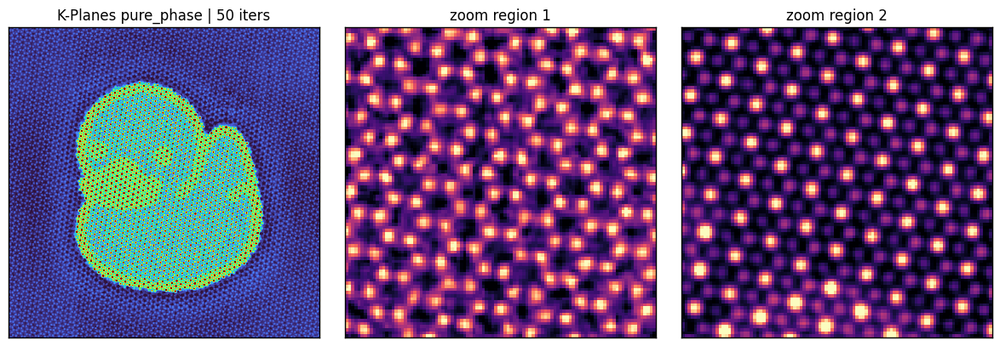

In [37]:
ph = ptycho_kp.obj_cropped.sum(0)
if ptycho_kp.obj_model.obj_type == "complex":
    ph = np.angle(ph)
show_2d(
    [ph, ph[r1], ph[r2]],
    cmap=("turbo", "magma", "magma"),
    title=[
        f"K-Planes {ptycho_kp.obj_model.obj_type} | {ptycho_kp.num_iters} iters",
        "zoom region 1",
        "zoom region 2",
    ],
)

  0%|          | 0/100 [00:00<?, ?it/s]

Iter 100/100, Loss: 4.439e+00: 100%|██████████| 100/100 [03:59<00:00,  2.40s/it]


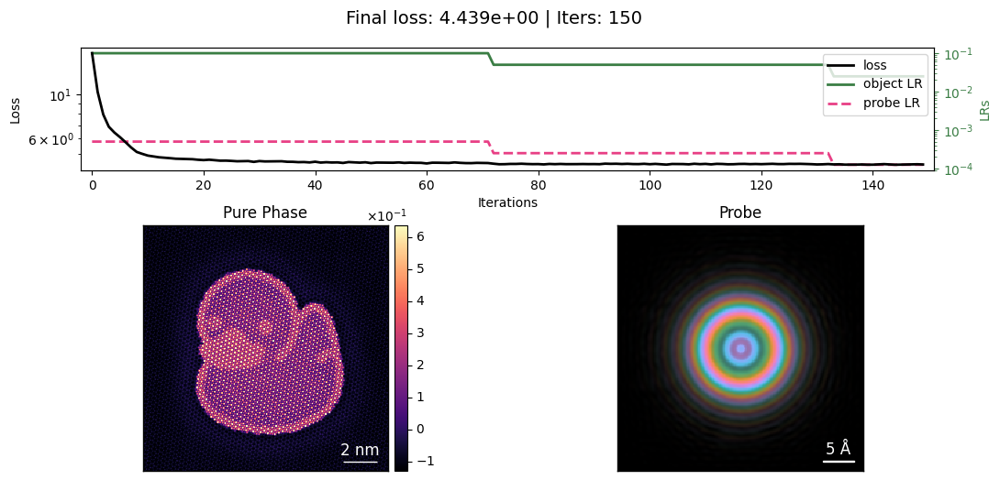

In [38]:
# Continue from the current state for a longer, higher-quality reconstruction.
ptycho_kp.reconstruct(num_iters=100).visualize()

(<Figure size 1200x400 with 3 Axes>,
 array([<Axes: title={'center': 'K-Planes pure_phase | 150 iters'}>,
        <Axes: title={'center': 'zoom region 1'}>,
        <Axes: title={'center': 'zoom region 2'}>], dtype=object))

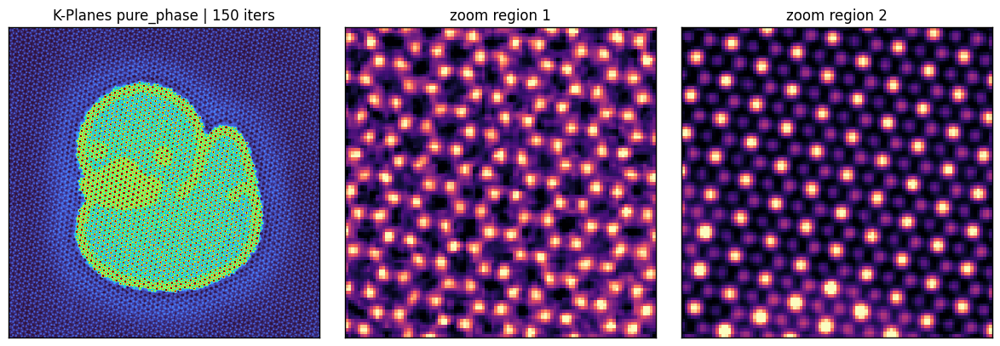

In [39]:
ph = ptycho_kp.obj_cropped.sum(0)
if ptycho_kp.obj_model.obj_type == "complex":
    ph = np.angle(ph)
show_2d(
    [ph, ph[r1], ph[r2]],
    cmap=("turbo", "magma", "magma"),
    title=[
        f"K-Planes {ptycho_kp.obj_model.obj_type} | {ptycho_kp.num_iters} iters",
        "zoom region 1",
        "zoom region 2",
    ],
)

### Comparison: pixelated vs DIP vs INR vs K-Planes

Side-by-side phase reconstructions from all four object models on the same dataset, with
zoomed views of each. The pixelated grid is the simplest and fastest; the DIP and implicit
models add learned / implicit priors. After tuning, the implicit models are competitive with
the pixelated and DIP baselines.

(<Figure size 1600x400 with 4 Axes>,
 array([<Axes: title={'center': 'pixelated | 250 iters'}>,
        <Axes: title={'center': 'DIP | 50 iters'}>,
        <Axes: title={'center': 'INR | 100 iters'}>,
        <Axes: title={'center': 'K-Planes | 150 iters'}>], dtype=object))

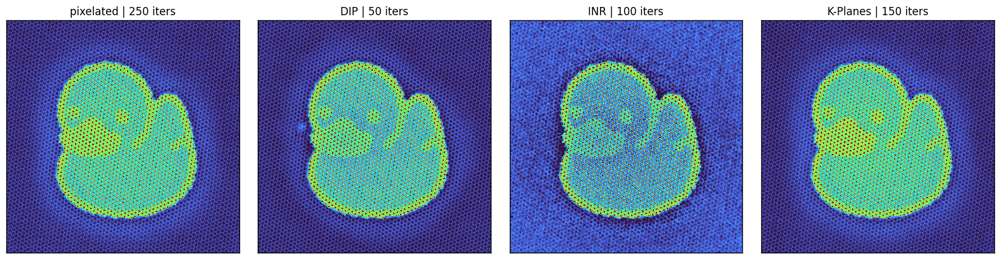

In [40]:
def _obj_phase(ptycho):
    ph = ptycho.obj_cropped.sum(0)
    return np.angle(ph) if ptycho.obj_model.obj_type == "complex" else ph


models = {
    "pixelated": ptycho_pix,
    "DIP": ptycho_dip,
    "INR": ptycho_inr,
    "K-Planes": ptycho_kp,
}
phases = {k: _obj_phase(p) for k, p in models.items()}
show_2d(
    list(phases.values()),
    cmap="turbo",
    title=[f"{k} | {p.num_iters} iters" for k, p in models.items()],
)

(<Figure size 1600x400 with 4 Axes>,
 array([<Axes: title={'center': 'pixelated (zoom 1)'}>,
        <Axes: title={'center': 'DIP (zoom 1)'}>,
        <Axes: title={'center': 'INR (zoom 1)'}>,
        <Axes: title={'center': 'K-Planes (zoom 1)'}>], dtype=object))

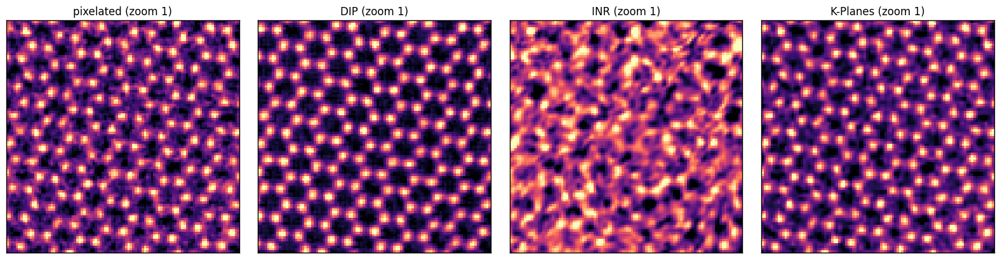

In [41]:
# Zoomed views of each reconstruction (region 1).
show_2d([phases[k][r1] for k in models], cmap="magma", title=[f"{k} (zoom 1)" for k in models])

(<Figure size 1600x400 with 4 Axes>,
 array([<Axes: title={'center': 'pixelated (zoom 2)'}>,
        <Axes: title={'center': 'DIP (zoom 2)'}>,
        <Axes: title={'center': 'INR (zoom 2)'}>,
        <Axes: title={'center': 'K-Planes (zoom 2)'}>], dtype=object))

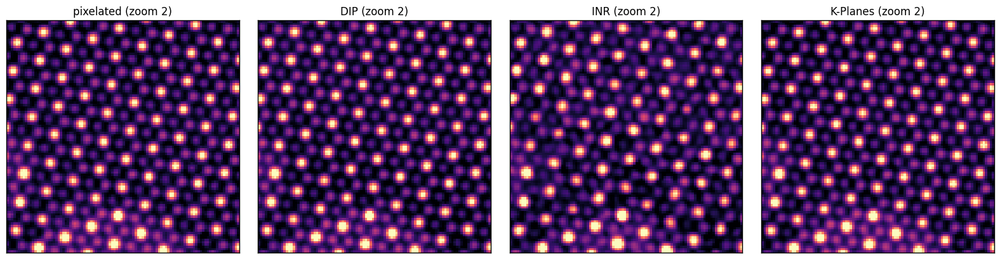

In [42]:
# Zoomed views of each reconstruction (region 2).
show_2d([phases[k][r2] for k in models], cmap="magma", title=[f"{k} (zoom 2)" for k in models])

-- End notebook --